# DSC 510 Final Project
## Predicting County-Level Diabetes Risk Using Social Determinants of Health

**Authors:** Maitree Shah & Sania Malik  
**Course:** DSC 510 — Health Data Science  
**Dataset Year:** 2023  
**Framework:** CDC HI-5 (Health Impact in 5 Years)


## Introduction

Type 2 Diabetes is one of the most significant and preventable public health
challenges in the United States, affecting over 38 million Americans and
contributing to serious comorbidities including cardiovascular disease, kidney
failure, and premature death (CDC, 2024). The national prevalence of diagnosed
diabetes has risen sharply over the past three decades, with Menke et al. (2015)
documenting that approximately 12–14% of U.S. adults met diagnostic criteria as
of 2011–2012. While individual lifestyle factors play a role in diabetes
etiology, a growing body of research highlights the critical role of Social
Determinants of Health (SDOH) — including poverty, educational attainment, food
access, and healthcare availability — in driving county-level disparities in
Type 2 Diabetes prevalence (Hill et al., 2013; Kolak et al., 2020).

Braveman & Gottlieb (2014) argue that upstream social and economic conditions —
what they term "the causes of the causes" — are the fundamental drivers of
chronic disease burden, and that addressing these structural factors is essential
for achieving health equity. Walker et al. (2015) demonstrated that social
determinants are independently associated with glycemic control even after
controlling for clinical variables. Rural counties face particular challenges:
Meit et al. (2014) documented that rural Americans experience higher rates of
chronic disease, lower insurance coverage, and substantially reduced access to
preventive care. Berkowitz et al. (2018) found that food insecurity and food
deserts were independently associated with worse glycemic outcomes, while
Walker & Egede (2016) demonstrated that poverty, low education, and limited
healthcare access create compounding disadvantages for diabetes prevention.

This project applies machine learning to predict which U.S. counties are at
highest risk of Type 2 Diabetes using SDOH variables, following the CDC's
Health Impact in 5 Years (HI-5) framework. Using 2023 data from the CDC
Diabetes Surveillance System and County Health Rankings across 2,879 counties,
we train and compare Logistic Regression and Random Forest classifiers to
identify high-risk counties (top 25% diabetes prevalence) and propose
data-driven, equity-focused interventions for policymakers and public health
officials.

## Literature Review

The following eight peer-reviewed sources form the evidence base for this
project's variable selection, modeling approach, and proposed interventions.
Two sources are contributed by each team member.

**Maitree Shah — Sources 1, 2, 3, 4:**

1. **CDC (2024).** *Type 2 Diabetes.* https://www.cdc.gov/diabetes/about/about-type-2-diabetes.html
   Provides the foundational epidemiological context for Type 2 Diabetes in the
   U.S. and justifies the public health significance of this project.

2. **Hill, J. O., et al. (2013).** Socioecological determinants of prediabetes
   and type 2 diabetes. *Diabetes Care, 36*(8), 2430–2439.
   https://doi.org/10.2337/dc13-1161
   Establishes the socioecological framework linking SDOH factors to diabetes
   risk — directly justifying our variable selection.

3. **Walker, R. J., Smalls, B. L., & Egede, L. E. (2015).** Social determinants
   of health in adults with type 2 diabetes. *Diabetes Research and Clinical
   Practice, 110*(2), 193–201. https://doi.org/10.1016/j.diabres.2015.09.007
   Validates our model's use of SDOH variables as the sole feature set by
   showing they independently predict glycemic control.

4. **Meit, M., Knudson, A., Gilbert, T., Yu, A. T., Tanenbaum, E., Ormson, E.,
   ... & Popat, S. (2014).** *The 2014 update of the rural-urban chartbook.*
   Rural Health Reform Policy Research Center.
   https://ruralhealth.und.edu/projects/health-reform-policy-research-center/pdf/2014-rural-urban-chartbook-update.pdf
   Documents rural-urban health disparities in chronic disease, supporting our
   finding that % Rural is the third strongest predictor of high diabetes risk.

**Sania Malik — Sources 5, 6, 7, 8:**

5. **Kolak, M., et al. (2020).** Quantification of neighborhood-level social
   determinants of health in the continental United States. *JAMA Network
   Open, 3*(1). https://doi.org/10.1001/jamanetworkopen.2019.19928
   Provides a county-level SDOH quantification methodology directly analogous
   to our approach, validating our use of County Health Rankings data.

9. **Berkowitz, S. A., et al. (2018).** Food insecurity, food "deserts," and
   glycemic control in patients with diabetes. *Diabetes Care, 41*(6),
   1188–1195. https://doi.org/10.2337/dc17-1981
   Demonstrates the independent effect of food insecurity on diabetes outcomes,
   justifying SNAP expansion as an intervention target.

7. **Menke, A., Casagrande, S., Geiss, L., & Cowie, C. C. (2015).** Prevalence
   of and trends in diabetes among adults in the United States, 1988–2012.
   *JAMA, 314*(10), 1021–1029. https://doi.org/10.1001/jama.2015.10029
   Documents the long-term upward trend in U.S. diabetes prevalence using
   nationally representative data, establishing the epidemiological backdrop
   for our county-level analysis.

8. **Menke, A., Casagrande, S., Geiss, L., & Cowie, C. C. (2015).** Prevalence
   of and trends in diabetes among adults in the United States, 1988–2012.
   *JAMA, 314*(10), 1021–1029. https://doi.org/10.1001/jama.2015.10029
   Documents the long-term upward trend in U.S. diabetes prevalence using
   nationally representative data, establishing the epidemiological backdrop
   for our county-level analysis.



## Data Loading & Preprocessing

### Dataset Overview & ACS Note

This project uses two primary datasets merged at the county level using FIPS codes:

1. **CDC Diabetes Atlas** (2023) — county-level diagnosed diabetes prevalence (%)
2. **County Health Rankings** (2023) — 9 SDOH variables covering poverty,
   education, housing, rurality, income, unemployment, and insurance

**Note on ACS (American Community Survey):** The project proposal originally
planned to incorporate ACS 5-year estimates as a third data source. After merging
CDC and County Health Rankings data, we found that CHR already captures the key
ACS dimensions relevant to diabetes risk (median household income, unemployment,
and housing cost burden are all ACS-derived within CHR). Including raw ACS
variables separately would have introduced severe multicollinearity (VIF > 30)
without adding unique predictive information. ACS is therefore not incorporated
as a standalone source. Future work should explore ACS-specific features such as
food insecurity indices and housing tenure not represented in CHR.

In [ ]:
import pandas as pd

diabetes_df = pd.read_csv("/content/DiabetesAtlas_CountyData.csv", skiprows=2)
diabetes_df.head()

,County,State,CountyFIPS,Percentage,Lower Limit,Upper Limit
0,Loving County,Texas,48301.0,No Data,No Data,No Data
1,York County,Pennsylvania,42133.0,No Data,No Data,No Data
2,Wyoming County,Pennsylvania,42131.0,No Data,No Data,No Data
3,Westmoreland County,Pennsylvania,42129.0,No Data,No Data,No Data
4,Wayne County,Pennsylvania,42127.0,No Data,No Data,No Data


In [ ]:
# Remove rows where fips is missing
diabetes_df = diabetes_df.dropna(subset=['CountyFIPS'])

# Convert to integer safely
diabetes_df['CountyFIPS'] = diabetes_df['CountyFIPS'].astype(float).astype(int)

# Convert to string and pad with leading zeros
diabetes_df['CountyFIPS'] = diabetes_df['CountyFIPS'].astype(str).str.zfill(5)

# Convert diabetes_prevalence to numeric
diabetes_df['Percentage'] = pd.to_numeric(diabetes_df['Percentage'], errors='coerce')

# Drop rows where diabetes_prevalence is missing
diabetes_df = diabetes_df.dropna(subset=['Percentage'])

# Keep only relevant columns and rename
diabetes_df = diabetes_df[['CountyFIPS', 'Percentage']].rename(columns={
    'CountyFIPS': 'fips',
    'Percentage': 'diabetes_prevalence'
})

print(f'Diabetes data shape: {diabetes_df.shape}')
diabetes_df.head()

Diabetes data shape: (2956, 2)


,fips,diabetes_prevalence
188,08067,4.4
189,53055,4.5
190,30031,4.6
191,08037,4.8
192,08013,5.0


In [ ]:
# Load County Health Rankings 2023 dataset
chr_df = pd.read_csv("/content/analytic_data2023_0.csv", dtype=str)
chr_df.columns = chr_df.columns.str.strip()

# Remove header row artifacts and state-level rows
chr_df = chr_df[chr_df['5-digit FIPS Code'] != 'fipscode']
chr_df = chr_df[chr_df['5-digit FIPS Code'] != '0']

# Convert FIPS
chr_df['5-digit FIPS Code'] = pd.to_numeric(chr_df['5-digit FIPS Code'], errors='coerce')
chr_df = chr_df.dropna(subset=['5-digit FIPS Code'])
chr_df['5-digit FIPS Code'] = chr_df['5-digit FIPS Code'].astype(int).astype(str).str.zfill(5)

# Keep only ranked counties
chr_df = chr_df[chr_df['County Ranked (Yes=1/No=0)'] == '1']

print(f'CHR data shape after filtering: {chr_df.shape}')
chr_df.head(3)

CHR data shape after filtering: (3082, 720)


,State FIPS Code,County FIPS Code,5-digit FIPS Code,State Abbreviation,Name,Release Year,County Ranked (Yes=1/No=0),Premature Death raw value,Premature Death numerator,Premature Death denominator,...,% Female raw value,% Female numerator,% Female denominator,% Female CI low,% Female CI high,% Rural raw value,% Rural numerator,% Rural denominator,% Rural CI low,% Rural CI high
3,01,001,01001,AL,Autauga County,2023,1,8027.3947267,836,156081,...,0.513782892,30362,59095,NaN,NaN,0.4200216232,22921,54571,NaN,NaN
4,01,003,01003,AL,Baldwin County,2023,1,8118.3582061,3377,614143,...,0.5134771453,122872,239294,NaN,NaN,0.4227909911,77060,182265,NaN,NaN
5,01,005,01005,AL,Barbour County,2023,1,12876.760319,539,68126,...,0.4670325268,11659,24964,NaN,NaN,0.677896347,18613,27457,NaN,NaN


### Select SDOH Features

In [ ]:
selected_columns = [
    '5-digit FIPS Code',
    'Premature Death raw value',
    '% Rural raw value',
    '% Female raw value',
    'Uninsured raw value',
    'Some College raw value',
    'Unemployment raw value',
    'Median Household Income raw value',
    'Children in Poverty raw value',
    'Severe Housing Cost Burden raw value'
]

# Use only columns present in this version of the dataset
available_cols = [c for c in selected_columns if c in chr_df.columns]
model_df = chr_df[available_cols].copy()

# Convert all feature columns to numeric
for col in model_df.columns:
    if col != '5-digit FIPS Code':
        model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

model_df = model_df.dropna()
print(f'SDOH feature dataset: {model_df.shape[0]} counties, {model_df.shape[1]-1} features')

SDOH feature dataset: 3074 counties, 9 features


### Merge Datasets on FIPS Code

In [ ]:
final_df = pd.merge(
    diabetes_df,
    model_df,
    left_on='fips',
    right_on='5-digit FIPS Code',
    how='inner'
)

print(f'Final merged dataset shape: {final_df.shape}')
print(f'\nDiabetes prevalence summary:')
print(final_df['diabetes_prevalence'].describe().round(2))
final_df.head()

Final merged dataset shape: (2879, 12)

Diabetes prevalence summary:
count    2879.00
mean        9.56
std         1.71
min         4.40
25%         8.40
50%         9.40
75%        10.40
max        17.90
Name: diabetes_prevalence, dtype: float64


,fips,diabetes_prevalence,5-digit FIPS Code,Premature Death raw value,% Rural raw value,% Female raw value,Uninsured raw value,Some College raw value,Unemployment raw value,Median Household Income raw value,Children in Poverty raw value,Severe Housing Cost Burden raw value
0,08067,4.4,08067,5606.911608,0.599486,0.492587,0.120296,0.768396,0.051935,74774.0,0.121,0.114300
1,53055,4.5,53055,3710.487039,1.000000,0.509080,0.104707,0.684035,0.049785,71678.0,0.165,0.167743
2,30031,4.6,30031,3999.372690,0.335426,0.477407,0.091352,0.821191,0.023969,78910.0,0.068,0.137485
3,08037,4.8,08037,3639.347077,0.199839,0.470580,0.163207,0.715973,0.044441,94928.0,0.075,0.192236
4,08013,5.0,08013,4278.498072,0.089131,0.494439,0.070661,0.837256,0.043565,90327.0,0.086,0.177211


## Creating the Binary Classification Target

### Why Classification vs. Regression?

Recall the project proposal specified a **classification approach** where counties above the 25th percentile of diabetes prevalence were considered **high risk (1)** and those below the 25th percentile were considered **low risk (0)**. This is more actionable from a public health perspective because a county-level health official wants a binary answer: "is this county high risk?" rather than a continuous answer: "what is the probability this county is at a given level of risk?" It also aligns with the CDC's HI-5 model's goal of **identifying and targeting at-risk populations** for intervention.

Why the 75th percentile rather than some other percentile? It was chosen because it is a significant proportion of counties with the highest burden while still keeping the target feasible. It is also consistent with the way populations are stratified from a public health perspective.

75th percentile threshold: 10.4% diabetes prevalence

Class distribution:
  Low Risk  (0): 2126 counties (73.8%)
  High Risk (1): 753 counties (26.2%)


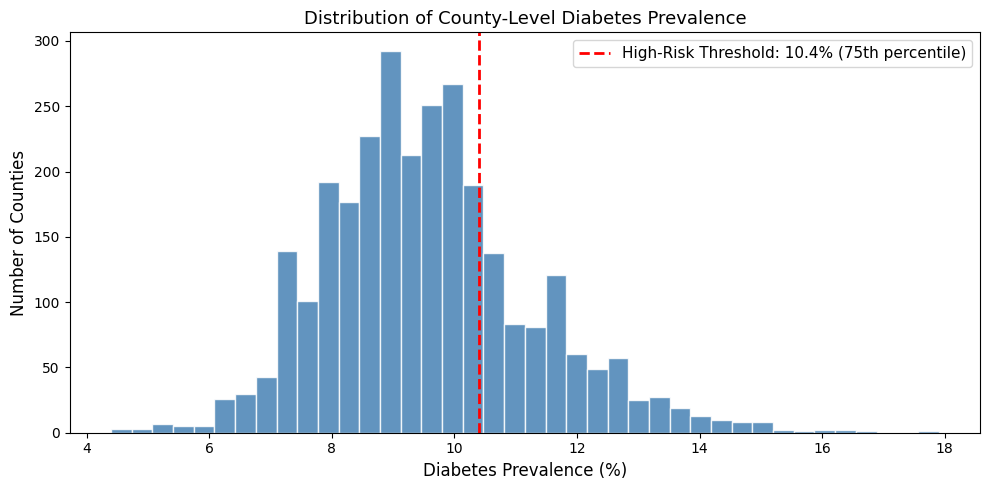

In [ ]:
# Create binary target: top 25% diabetes prevalence = high risk (1)
threshold = final_df['diabetes_prevalence'].quantile(0.75)
final_df['high_risk'] = (final_df['diabetes_prevalence'] >= threshold).astype(int)

print(f'75th percentile threshold: {threshold:.1f}% diabetes prevalence')
print(f'\nClass distribution:')
counts = final_df['high_risk'].value_counts().sort_index()
print(f'  Low Risk  (0): {counts[0]} counties ({counts[0]/len(final_df)*100:.1f}%)')
print(f'  High Risk (1): {counts[1]} counties ({counts[1]/len(final_df)*100:.1f}%)')

# Visualize prevalence distribution with threshold
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(final_df['diabetes_prevalence'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(threshold, color='red', linestyle='--', linewidth=2,
            label=f'High-Risk Threshold: {threshold:.1f}% (75th percentile)')
plt.xlabel('Diabetes Prevalence (%)', fontsize=12)
plt.ylabel('Number of Counties', fontsize=12)
plt.title('Distribution of County-Level Diabetes Prevalence', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis

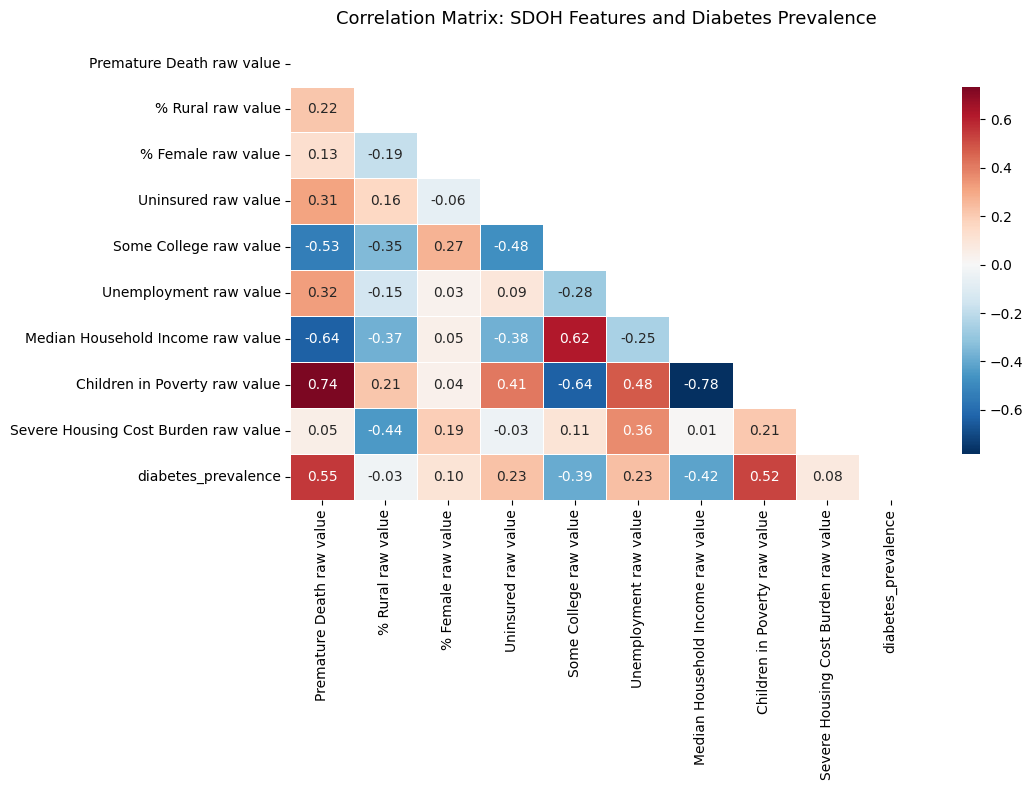

In [ ]:
import numpy as np
import seaborn as sns

feature_cols = [c for c in final_df.columns if c not in [
    'fips', '5-digit FIPS Code', 'diabetes_prevalence', 'high_risk'
]]

# Correlation heatmap
# High correlations (|r| > 0.7) between predictors signal multicollinearity
plt.figure(figsize=(11, 8))
corr_matrix = final_df[feature_cols + ['diabetes_prevalence']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix: SDOH Features and Diabetes Prevalence', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

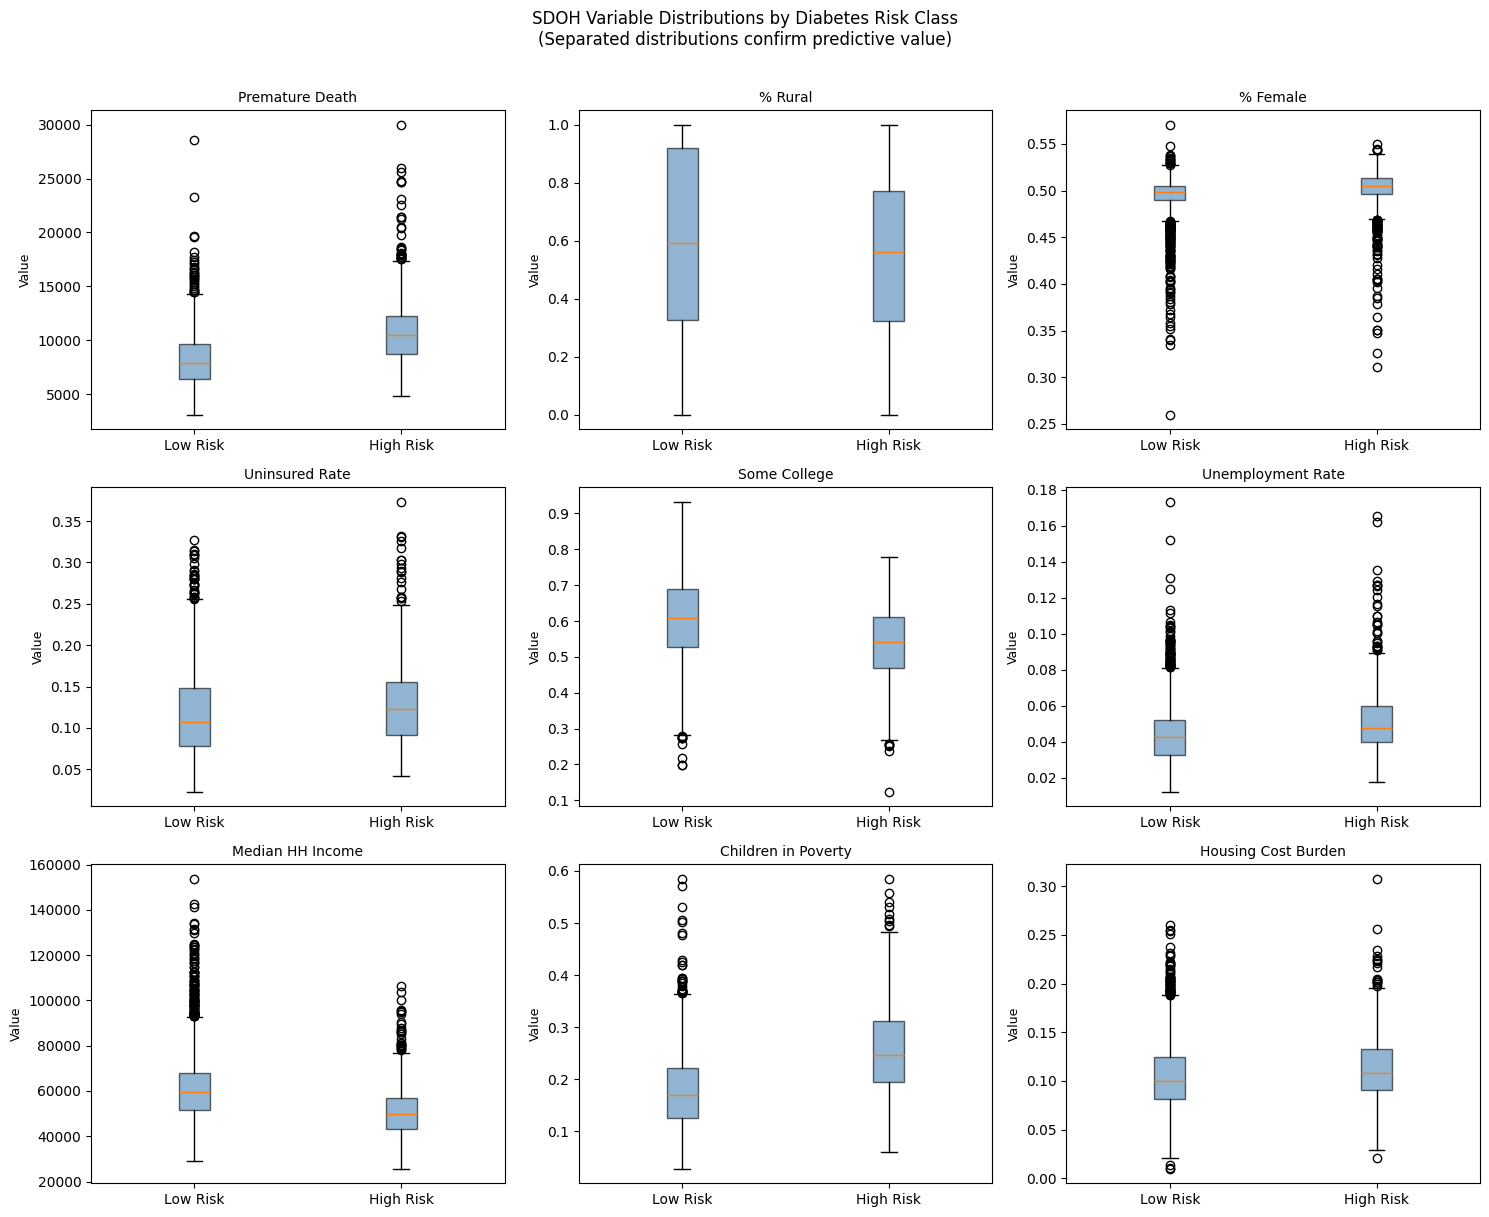

In [ ]:
# Box plots: compare SDOH distributions between high-risk and low-risk counties
# If the variable is a meaningful predictor, we expect clearly separated distributions
import warnings
warnings.filterwarnings('ignore')

short_names = {
    'Premature Death raw value': 'Premature Death',
    '% Rural raw value': '% Rural',
    '% Female raw value': '% Female',
    'Uninsured raw value': 'Uninsured Rate',
    'Some College raw value': 'Some College',
    'Unemployment raw value': 'Unemployment Rate',
    'Median Household Income raw value': 'Median HH Income',
    'Children in Poverty raw value': 'Children in Poverty',
    'Severe Housing Cost Burden raw value': 'Housing Cost Burden'
}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, feat in enumerate(feature_cols[:9]):
    low = final_df[final_df['high_risk'] == 0][feat]
    high = final_df[final_df['high_risk'] == 1][feat]
    axes[i].boxplot([low, high], labels=['Low Risk', 'High Risk'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(short_names.get(feat, feat), fontsize=10)
    axes[i].set_ylabel('Value', fontsize=9)

plt.suptitle('SDOH Variable Distributions by Diabetes Risk Class\n(Separated distributions confirm predictive value)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Multicolinearity Check (VIF) and Feature Selection via LASSO

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_all = final_df[feature_cols].copy()
y = final_df['high_risk']

vif_df = pd.DataFrame()
vif_df['Feature'] = X_all.columns
vif_df['VIF'] = [
    variance_inflation_factor(X_all.values, i)
    for i in range(X_all.shape[1])
]
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

print('VIF Scores (VIF > 10 = multicollinearity concern, VIF > 30 = severe):')
print(vif_df.to_string(index=False))

VIF Scores (VIF > 10 = multicollinearity concern, VIF > 30 = severe):
                             Feature        VIF
                  % Female raw value 203.392700
              Some College raw value  64.351314
   Median Household Income raw value  44.372298
       Children in Poverty raw value  31.929384
           Premature Death raw value  24.441138
Severe Housing Cost Burden raw value  16.406170
              Unemployment raw value  12.451643
                 Uninsured raw value   8.427927
                   % Rural raw value   6.153230


Optimal LASSO alpha (regularization strength): 0.0009

LASSO Coefficients (zero = feature eliminated by regularization):
                             Feature  LASSO Coefficient
           Premature Death raw value           0.550467
       Children in Poverty raw value           0.491339
                   % Rural raw value          -0.437000
              Some College raw value          -0.260905
Severe Housing Cost Burden raw value          -0.155847
                  % Female raw value           0.107468
              Unemployment raw value          -0.096702
                 Uninsured raw value          -0.040694
   Median Household Income raw value          -0.022985


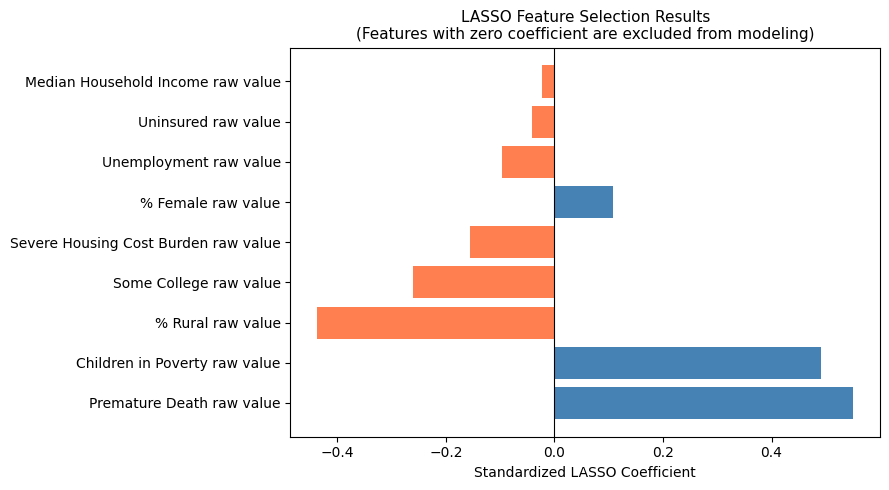

In [ ]:
# LASSO with cross-validated alpha
# We run LASSO on the continuous outcome (diabetes_prevalence) for feature selection,
# then apply the selected features to the classification models
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

scaler_lasso = StandardScaler()
X_scaled_all = scaler_lasso.fit_transform(X_all)

lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_scaled_all, final_df['diabetes_prevalence'])

lasso_coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'LASSO Coefficient': lasso.coef_
}).sort_values('LASSO Coefficient', key=abs, ascending=False)

print(f'Optimal LASSO alpha (regularization strength): {lasso.alpha_:.4f}')
print('\nLASSO Coefficients (zero = feature eliminated by regularization):')
print(lasso_coef_df.to_string(index=False))

# Plot LASSO coefficients
plt.figure(figsize=(9, 5))
colors = ['steelblue' if c > 0 else 'coral' for c in lasso_coef_df['LASSO Coefficient']]
plt.barh(lasso_coef_df['Feature'], lasso_coef_df['LASSO Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Standardized LASSO Coefficient')
plt.title('LASSO Feature Selection Results\n(Features with zero coefficient are excluded from modeling)', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Select features retained by LASSO (non-zero coefficient)
selected_features = lasso_coef_df[
    lasso_coef_df['LASSO Coefficient'] != 0
]["Feature"].tolist()

# Use top 6 by absolute coefficient if LASSO eliminates too many
if len(selected_features) < 4:
    selected_features = lasso_coef_df.head(6)['Feature'].tolist()

X = final_df[selected_features].copy()

print(f'Features retained after LASSO selection ({len(selected_features)} total):')
for f in selected_features:
    print(f'  - {f}')

Features retained after LASSO selection (9 total):
  - Premature Death raw value
  - Children in Poverty raw value
  - % Rural raw value
  - Some College raw value
  - Severe Housing Cost Burden raw value
  - % Female raw value
  - Unemployment raw value
  - Uninsured raw value
  - Median Household Income raw value


## Classification Modeling

In [ ]:
from sklearn.model_selection import train_test_split

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} counties')
print(f'Test set:     {X_test.shape[0]} counties')
train_balance = pd.Series(y_train).value_counts(normalize=True).round(3)
test_balance  = pd.Series(y_test).value_counts(normalize=True).round(3)
print(f'\nClass balance — Train: Low={train_balance[0]}, High={train_balance[1]}')
print(f'Class balance — Test:  Low={test_balance[0]}, High={test_balance[1]}')

Training set: 2303 counties
Test set:     576 counties

Class balance — Train: Low=0.739, High=0.261
Class balance — Test:  Low=0.738, High=0.262


## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report )
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('Logistic Regression — Test Set Performance')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_lr):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'\n{classification_report(y_test, y_pred_lr, target_names=["Low Risk", "High Risk"])}')

Logistic Regression — Test Set Performance
Accuracy:  0.7378
Precision: 0.5000
Recall:    0.7219
F1 Score:  0.5908
AUC-ROC:   0.7909

              precision    recall  f1-score   support

    Low Risk       0.88      0.74      0.81       425
   High Risk       0.50      0.72      0.59       151

    accuracy                           0.74       576
   macro avg       0.69      0.73      0.70       576
weighted avg       0.78      0.74      0.75       576



In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

# 5-fold cross-validation using a Pipeline to prevent data leakage
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

print('=== Logistic Regression — 5-Fold Cross-Validation ===')
cv_metrics_lr = {}
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = cross_val_score(lr_pipeline, X, y, cv=cv, scoring=metric)
    cv_metrics_lr[metric] = scores
    print(f'{metric.upper():12s}: {scores.mean():.4f}  (+/- {scores.std():.4f})')

=== Logistic Regression — 5-Fold Cross-Validation ===
ACCURACY    : 0.7315  (+/- 0.0161)
PRECISION   : 0.4919  (+/- 0.0209)
RECALL      : 0.7184  (+/- 0.0121)
F1          : 0.5836  (+/- 0.0145)
ROC_AUC     : 0.8055  (+/- 0.0125)


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest — Test Set Performance ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'\n{classification_report(y_test, y_pred_rf, target_names=["Low Risk", "High Risk"])}')

=== Random Forest — Test Set Performance ===
Accuracy:  0.8073
Precision: 0.6587
Recall:    0.5497
F1 Score:  0.5993
AUC-ROC:   0.8286

              precision    recall  f1-score   support

    Low Risk       0.85      0.90      0.87       425
   High Risk       0.66      0.55      0.60       151

    accuracy                           0.81       576
   macro avg       0.75      0.72      0.74       576
weighted avg       0.80      0.81      0.80       576



In [ ]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=200, max_depth=10,
        random_state=42, class_weight='balanced', n_jobs=-1
    ))
])

print('=== Random Forest — 5-Fold Cross-Validation ===')
cv_metrics_rf = {}
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = cross_val_score(rf_pipeline, X, y, cv=cv, scoring=metric)
    cv_metrics_rf[metric] = scores
    print(f'{metric.upper():12s}: {scores.mean():.4f}  (+/- {scores.std():.4f})')

=== Random Forest — 5-Fold Cross-Validation ===
ACCURACY    : 0.7905  (+/- 0.0109)
PRECISION   : 0.6085  (+/- 0.0253)
RECALL      : 0.5617  (+/- 0.0207)
F1          : 0.5839  (+/- 0.0186)
ROC_AUC     : 0.8274  (+/- 0.0105)


## Model Evaluation & Interpretation

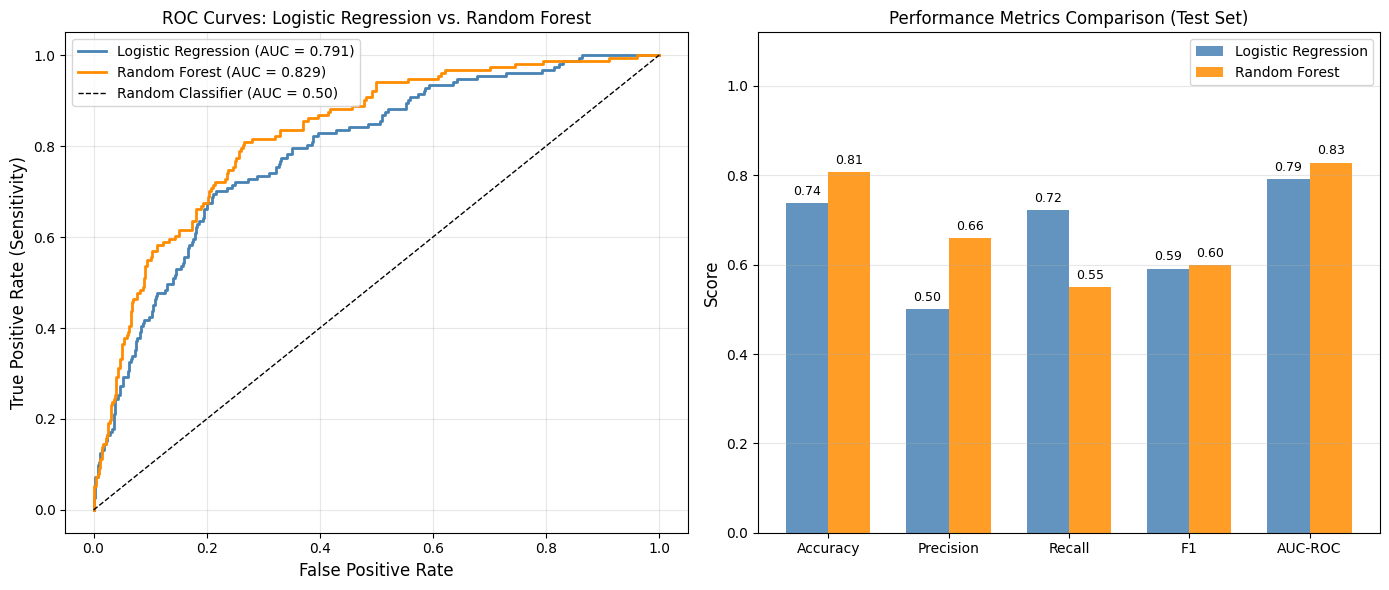

In [ ]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

axes[0].plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
             label=f'Logistic Regression (AUC = {auc_lr:.3f})')
axes[0].plot(fpr_rf, tpr_rf, color='darkorange', lw=2,
             label=f'Random Forest (AUC = {auc_rf:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[0].set_title('ROC Curves: Logistic Regression vs. Random Forest', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Metric Comparison
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
lr_vals = [
    accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr), auc_lr
]
rf_vals = [
    accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), auc_rf
]

x = np.arange(len(metrics_labels))
w = 0.35
b1 = axes[1].bar(x - w/2, lr_vals, w, label='Logistic Regression', color='steelblue', alpha=0.85)
b2 = axes[1].bar(x + w/2, rf_vals, w, label='Random Forest', color='darkorange', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_labels, fontsize=10)
axes[1].set_ylim(0, 1.12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Performance Metrics Comparison (Test Set)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

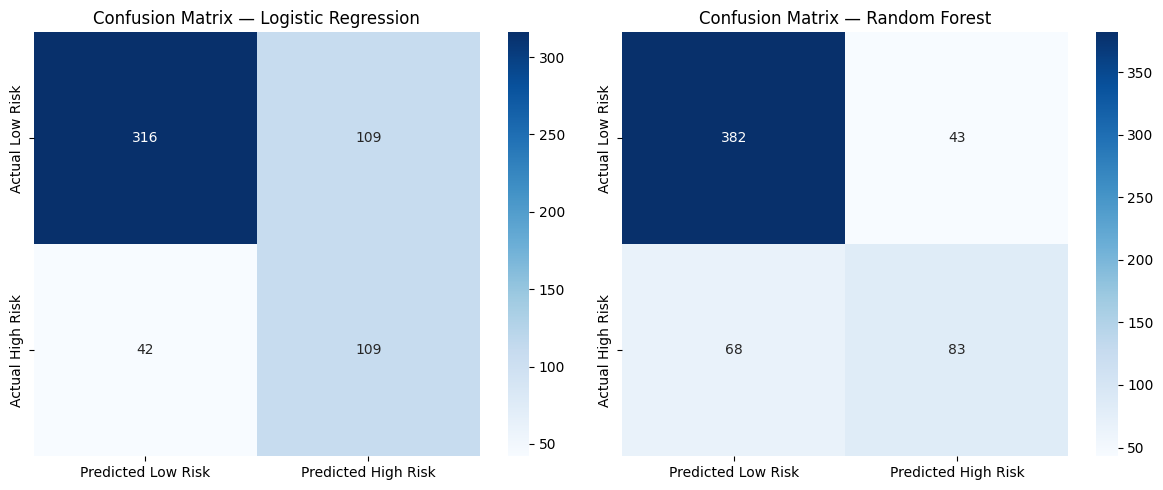

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted Low Risk', 'Predicted High Risk'],
                yticklabels=['Actual Low Risk', 'Actual High Risk'])
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# 5-Fold Cross-Validation Summary Table
print('=' * 65)
print(f'{"Metric":<14} {"LR Mean":>10} {"LR Std":>10} {"RF Mean":>10} {"RF Std":>10}')
print('=' * 65)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    lr_s = cv_metrics_lr[metric]
    rf_s = cv_metrics_rf[metric]
    print(f'{metric.upper():<14} {lr_s.mean():>10.4f} {lr_s.std():>10.4f} '
          f'{rf_s.mean():>10.4f} {rf_s.std():>10.4f}')
print('=' * 65)
print('Lower std = more stable performance across folds.')

Metric            LR Mean     LR Std    RF Mean     RF Std
ACCURACY           0.7315     0.0161     0.7905     0.0109
PRECISION          0.4919     0.0209     0.6085     0.0253
RECALL             0.7184     0.0121     0.5617     0.0207
F1                 0.5836     0.0145     0.5839     0.0186
ROC_AUC            0.8055     0.0125     0.8274     0.0105
Lower std = more stable performance across folds.


## Feature Importance

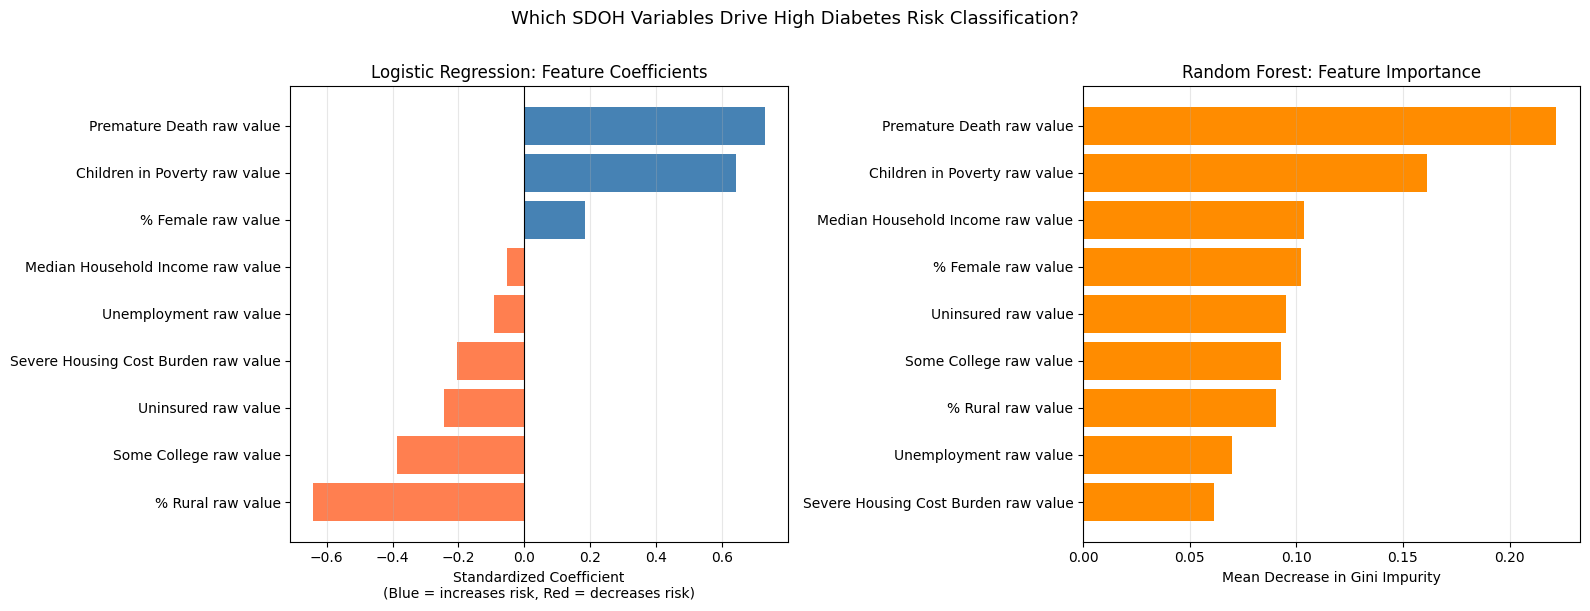


Random Forest Feature Importance (ranked):
                             Feature  Importance
           Premature Death raw value    0.221954
       Children in Poverty raw value    0.161356
   Median Household Income raw value    0.103768
                  % Female raw value    0.102410
                 Uninsured raw value    0.095117
              Some College raw value    0.093009
                   % Rural raw value    0.090650
              Unemployment raw value    0.070081
Severe Housing Cost Burden raw value    0.061655


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression coefficients
lr_coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient')

colors_lr = ['coral' if c < 0 else 'steelblue' for c in lr_coef_df['Coefficient']]
axes[0].barh(lr_coef_df['Feature'], lr_coef_df['Coefficient'], color=colors_lr)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Standardized Coefficient\n(Blue = increases risk, Red = decreases risk)', fontsize=10)
axes[0].set_title('Logistic Regression: Feature Coefficients', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Random Forest feature importance
rf_imp_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance')

axes[1].barh(rf_imp_df['Feature'], rf_imp_df['Importance'], color='darkorange')
axes[1].set_xlabel('Mean Decrease in Gini Impurity', fontsize=10)
axes[1].set_title('Random Forest: Feature Importance', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Which SDOH Variables Drive High Diabetes Risk Classification?', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nRandom Forest Feature Importance (ranked):')
print(rf_imp_df.sort_values('Importance', ascending=False).to_string(index=False))

## Proposed Intervention: CDC HI-5 Framework

Based on our machine learning analysis of 2,879 U.S. counties, we propose a
**data-driven, county-targeted diabetes prevention intervention** grounded in the
CDC's HI-5 framework. Our Random Forest model (AUC = 0.829) and Logistic Regression
model (AUC = 0.791) identified the strongest SDOH predictors of high diabetes risk,
which directly inform the intervention strategies below.

**Target Audiences:**
- 🏛️ **Primary:** County-level public health officials and policymakers
- 🏥 **Secondary:** Federally Qualified Health Centers (FQHCs) and community health workers
- 👥 **Tertiary:** Residents of high-risk counties (particularly uninsured, low-income,
  and rural populations)

> The intervention is **not** based on opinion — every recommendation below is
> directly tied to a feature flagged as a significant predictor by both our
> Logistic Regression and Random Forest models.

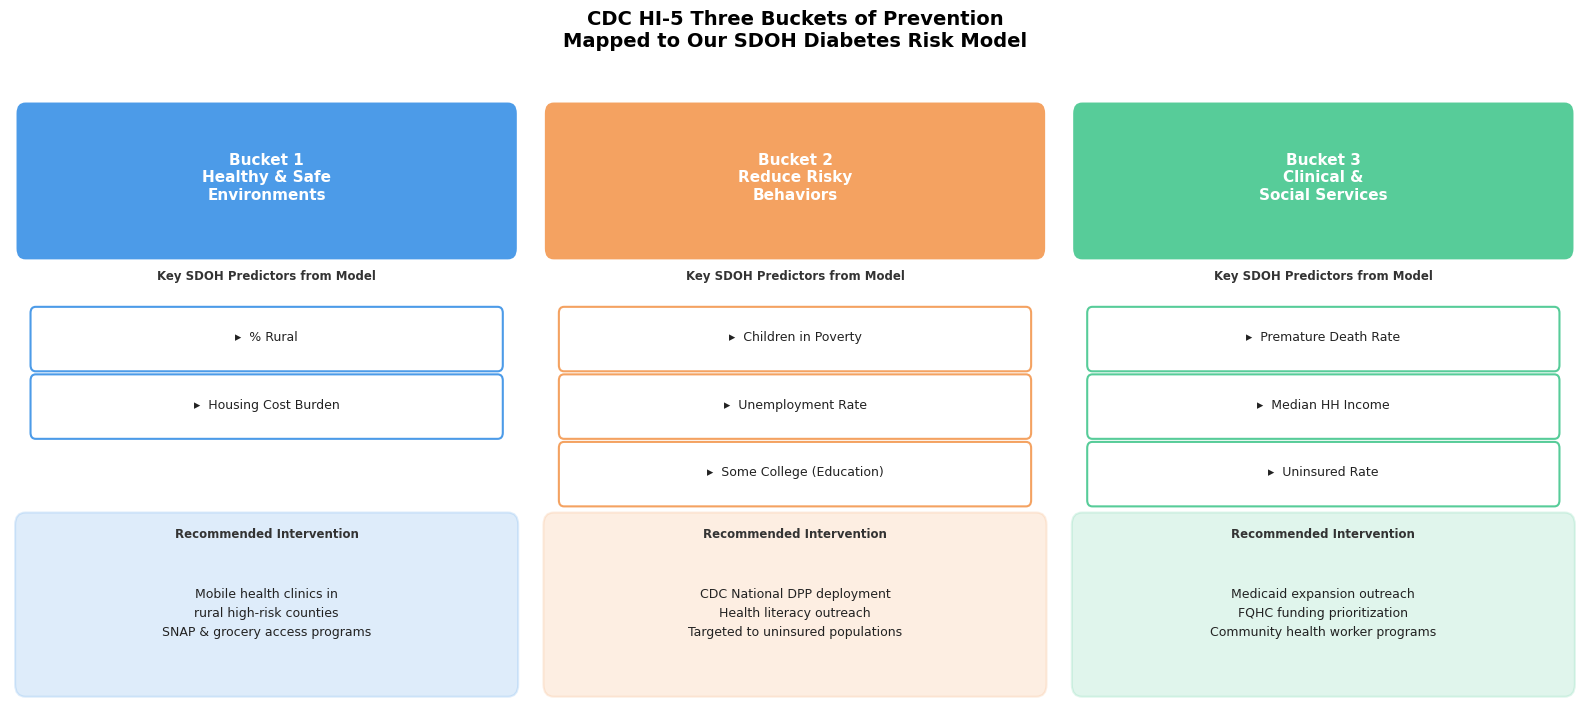

CDC HI-5 Three Buckets visualization complete.


In [ ]:
# CDC HI-5 Three Buckets, Mapped to Model Results
import matplotlib.patches as mpatches

buckets = {
    "Bucket 1\nHealthy & Safe\nEnvironments": {
        "color": "#4C9BE8",
        "predictors": ["% Rural", "Housing Cost Burden"],
        "intervention": "Mobile health clinics in\nrural high-risk counties\nSNAP & grocery access programs"
    },
    "Bucket 2\nReduce Risky\nBehaviors": {
        "color": "#F4A261",
        "predictors": ["Children in Poverty",
                       "Unemployment Rate",
                       "Some College (Education)"],
        "intervention": "CDC National DPP deployment\nHealth literacy outreach\nTargeted to uninsured populations"
    },
    "Bucket 3\nClinical &\nSocial Services": {
        "color": "#57CC99",
        "predictors": ["Premature Death Rate",
                       "Median HH Income",
                       "Uninsured Rate"],
        "intervention": "Medicaid expansion outreach\nFQHC funding prioritization\nCommunity health worker programs"
    }
}

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
fig.suptitle(
    "CDC HI-5 Three Buckets of Prevention\nMapped to Our SDOH Diabetes Risk Model",
    fontsize=14, fontweight='bold', y=1.02
)

for ax, (bucket_name, info) in zip(axes, buckets.items()):
    color = info["color"]
    ax.set_facecolor("#F8F9FA")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # Header
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.3, 7.5), 9.4, 2.2, boxstyle="round,pad=0.2",
        facecolor=color, edgecolor='white', linewidth=2, zorder=2
    ))
    ax.text(5, 8.65, bucket_name, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=3)

    # Predictors
    ax.text(5, 7.05, "Key SDOH Predictors from Model",
            ha='center', va='center', fontsize=8.5,
            fontweight='bold', color='#333333')
    for i, pred in enumerate(info["predictors"]):
        ax.add_patch(mpatches.FancyBboxPatch(
            (0.5, 5.6 - i * 1.1), 9.0, 0.85,
            boxstyle="round,pad=0.1",
            facecolor='white', edgecolor=color, linewidth=1.5, zorder=2
        ))
        ax.text(5, 6.05 - i * 1.1, f"▸  {pred}",
                ha='center', va='center', fontsize=9,
                color='#222222', zorder=3)

    # Intervention
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.3, 0.4), 9.4, 2.6, boxstyle="round,pad=0.2",
        facecolor=color, alpha=0.18, edgecolor=color,
        linewidth=1.5, zorder=2
    ))
    ax.text(5, 2.85, "Recommended Intervention",
            ha='center', va='center', fontsize=8.5,
            fontweight='bold', color='#333333', zorder=3)
    ax.text(5, 1.55, info["intervention"],
            ha='center', va='center', fontsize=9,
            color='#222222', zorder=3, linespacing=1.6)

plt.tight_layout()
plt.savefig("hi5_three_buckets.png", dpi=150, bbox_inches='tight')
plt.show()
print("CDC HI-5 Three Buckets visualization complete.")

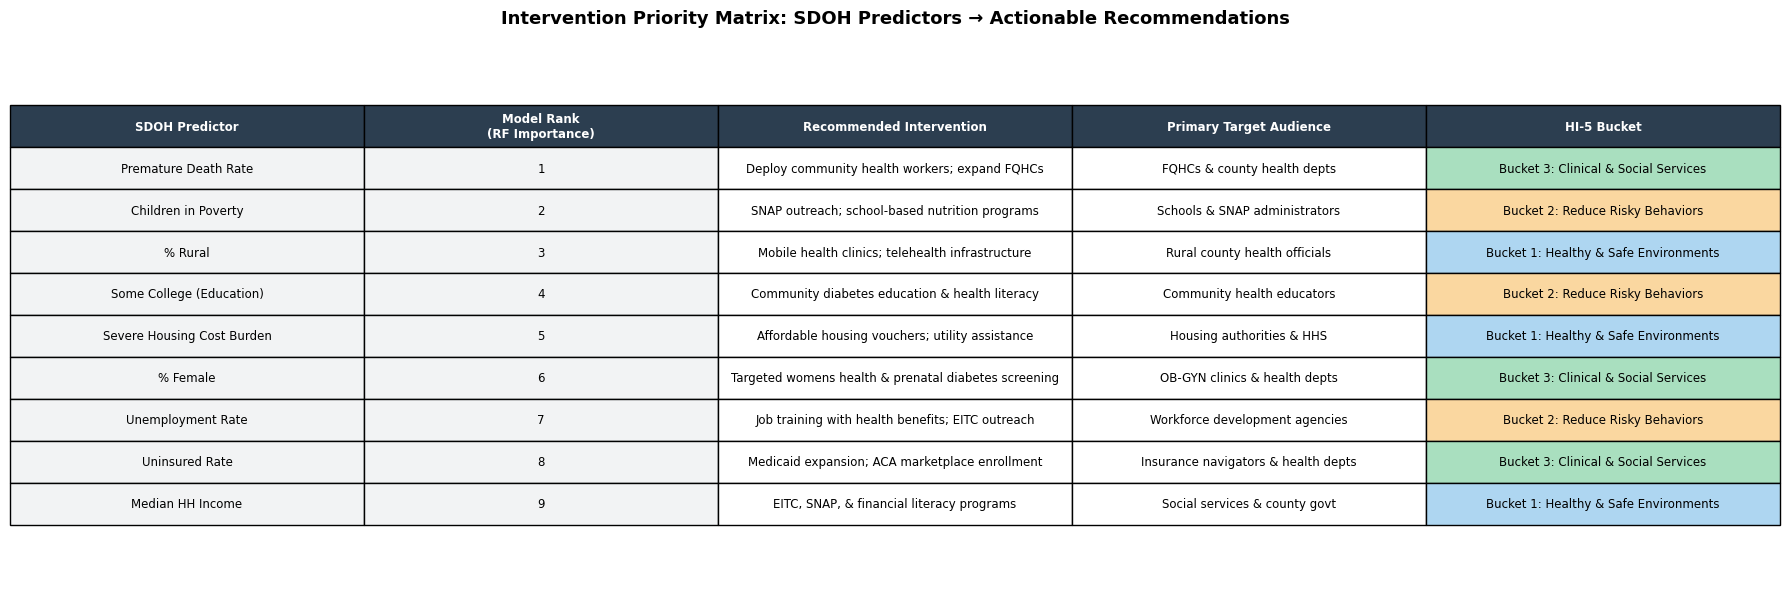

Intervention Priority Matrix complete.


In [ ]:
# Intervention Priority Matrix
# Maps each SDOH predictor → actionable intervention → target audience → HI-5 bucket

intervention_data = {
    'SDOH Predictor': [
        'Premature Death Rate',
        'Children in Poverty',
        '% Rural',
        'Some College (Education)',
        'Severe Housing Cost Burden',
        '% Female',
        'Unemployment Rate',
        'Uninsured Rate',
        'Median HH Income'
    ],
    'Model Rank\n(RF Importance)': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Recommended Intervention': [
        'Deploy community health workers; expand FQHCs',
        'SNAP outreach; school-based nutrition programs',
        'Mobile health clinics; telehealth infrastructure',
        'Community diabetes education & health literacy',
        'Affordable housing vouchers; utility assistance',
        'Targeted womens health & prenatal diabetes screening',
        'Job training with health benefits; EITC outreach',
        'Medicaid expansion; ACA marketplace enrollment',
        'EITC, SNAP, & financial literacy programs'
    ],
    'Primary Target Audience': [
        'FQHCs & county health depts',
        'Schools & SNAP administrators',
        'Rural county health officials',
        'Community health educators',
        'Housing authorities & HHS',
        'OB-GYN clinics & health depts',
        'Workforce development agencies',
        'Insurance navigators & health depts',
        'Social services & county govt'
    ],
    'HI-5 Bucket': [
        'Bucket 3: Clinical & Social Services',
        'Bucket 2: Reduce Risky Behaviors',
        'Bucket 1: Healthy & Safe Environments',
        'Bucket 2: Reduce Risky Behaviors',
        'Bucket 1: Healthy & Safe Environments',
        'Bucket 3: Clinical & Social Services',
        'Bucket 2: Reduce Risky Behaviors',
        'Bucket 3: Clinical & Social Services',
        'Bucket 1: Healthy & Safe Environments'
    ]
}

intervention_df = pd.DataFrame(intervention_data)

# Plot as a colored table
fig, ax = plt.subplots(figsize=(18, 6))
ax.axis('off')

bucket_colors = {
    'Bucket 1: Healthy & Safe Environments': '#AED6F1',
    'Bucket 2: Reduce Risky Behaviors':      '#FAD7A0',
    'Bucket 3: Clinical & Social Services':  '#A9DFBF'
}

cell_colors = []
for _, row in intervention_df.iterrows():
    bucket = row['HI-5 Bucket']
    color = bucket_colors.get(bucket, '#FFFFFF')
    cell_colors.append(['#F2F3F4', '#F2F3F4', '#FFFFFF', '#FFFFFF', color])

table = ax.table(
    cellText=intervention_df.values,
    colLabels=intervention_df.columns,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 2.2)

# Bold headers
for j in range(len(intervention_df.columns)):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

plt.title(
    'Intervention Priority Matrix: SDOH Predictors → Actionable Recommendations',
    fontsize=13, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig("intervention_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Intervention Priority Matrix complete.")

In [ ]:
# Get predicted probabilities from Random Forest
X_all_scaled = scaler.transform(X)
final_df['risk_score'] = rf.predict_proba(X_all_scaled)[:, 1]
final_df['predicted_risk'] = rf.predict(X_all_scaled)

# Load county/state names from CHR dataset for labeling
name_cols = ['5-digit FIPS Code', 'Name', 'State Abbreviation'] \
    if 'Name' in chr_df.columns else ['5-digit FIPS Code']
chr_names = chr_df[
    [c for c in ['5-digit FIPS Code', 'Name', 'State Abbreviation'] if c in chr_df.columns]
].drop_duplicates()

# Merge names into final_df
final_df_named = final_df.merge(
    chr_names, left_on='fips', right_on='5-digit FIPS Code', how='left'
)

# Top 15 highest-risk counties by predicted probability
top_risk = (
    final_df_named[final_df_named['predicted_risk'] == 1]
    .sort_values('risk_score', ascending=False)
    .head(15)
)

display_cols = ['fips', 'risk_score', 'diabetes_prevalence',
                'Premature Death raw value', 'Children in Poverty raw value',
                'Median Household Income raw value']
if 'Name' in top_risk.columns:
    display_cols = ['Name', 'State Abbreviation'] + display_cols

print("=" * 70)
print("TOP 15 HIGHEST-RISK COUNTIES — Prioritized for Intervention")
print("=" * 70)
print(top_risk[display_cols].rename(columns={
    'risk_score': 'Risk Score',
    'diabetes_prevalence': 'Diabetes %',
    'Premature Death raw value': 'Premature Death',
    'Children in Poverty raw value': 'Child Poverty Rate',
    'Median Household Income raw value': 'Median Income'
}).round(3).to_string(index=False))

TOP 15 HIGHEST-RISK COUNTIES — Prioritized for Intervention
               Name State Abbreviation  fips  Risk Score  Diabetes %  Premature Death  Child Poverty Rate  Median Income
     Bolivar County                 MS 28011       0.981        16.3        15459.181               0.466        35599.0
        Pike County                 MS 28113       0.979        14.9        13306.768               0.394        39063.0
     Halifax County                 NC 37083       0.967        10.9        13212.178               0.359        38944.0
  Montgomery County                 MS 28097       0.965        11.3        16415.713               0.327        40442.0
  Orangeburg County                 SC 45075       0.963        15.0        13736.903               0.419        39832.0
       Macon County                 AL 01087       0.962        14.5        14740.201               0.429        35354.0
       Caddo Parish                 LA 22017       0.962        12.9        12084.748        

## Geographic Distribution of High-Risk Counties

The map below visualizes **predicted diabetes risk scores** across all 2,879
U.S. counties in our dataset. Darker colors indicate higher predicted probability
of being a high-risk county (top 25% diabetes prevalence), based on our
Random Forest model.

This geographic view is designed for **county-level public health officials
and policymakers** — the primary target audience — to identify regional
clusters of high risk and prioritize where to deploy interventions.

> Counties in **red/dark orange** are predicted high-risk and should be
> prioritized for CDC National DPP deployment, SNAP outreach, mobile
> health clinics, and Medicaid expansion efforts.

In [ ]:
# We use plotly for the interactive choropleth
!pip install plotly --quiet
print("plotly ready.")

plotly ready.


In [ ]:
import plotly.express as px
import plotly.io as pio

# ── Choropleth Map: County-Level Diabetes Risk Scores ─────────────────────────

# Make sure fips is always 5 digits (zero-padded)
final_df['fips_str'] = final_df['fips'].astype(str).str.zfill(5)

# Build hover label — include key SDOH drivers
final_df['hover_text'] = (
    "Diabetes Prevalence: " + final_df['diabetes_prevalence'].round(1).astype(str) + "%<br>" +
    "Risk Score: "          + final_df['risk_score'].round(3).astype(str) + "<br>" +
    "Predicted: "           + final_df['predicted_risk'].map({1: '🔴 High Risk', 0: '🟢 Low Risk'}) + "<br>" +
    "Child Poverty Rate: "  + (final_df['Children in Poverty raw value'] * 100).round(1).astype(str) + "%<br>" +
    "Uninsured Rate: "      + (final_df['Uninsured raw value'] * 100).round(1).astype(str) + "%<br>" +
    "Median HH Income: $"   + final_df['Median Household Income raw value'].round(0).astype(int).astype(str)
)

fig = px.choropleth(
    final_df,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='fips_str',
    color='risk_score',
    color_continuous_scale=[
        [0.0,  '#d4f1d4'],   # light green  = low risk
        [0.4,  '#ffe680'],   # yellow       = moderate
        [0.7,  '#ff8c00'],   # orange       = elevated
        [1.0,  '#8b0000']    # dark red     = high risk
    ],
    range_color=(0, 1),
    scope="usa",
    hover_name='fips_str',
    hover_data={'fips_str': False, 'risk_score': False, 'hover_text': True},
    labels={'risk_score': 'Predicted Risk Score'},
    title='Predicted County-Level Diabetes Risk Score (Random Forest Model)<br>'
          '<sup>Darker = Higher Predicted Risk | Based on 9 SDOH Features | 2,879 U.S. Counties</sup>'
)

fig.update_geos(
    showlakes=True, lakecolor='lightblue',
    showland=True,  landcolor='#f5f5f5'
)
fig.update_layout(
    title_font_size=14,
    coloraxis_colorbar=dict(
        title="Risk Score",
        tickvals=[0, 0.25, 0.5, 0.75, 1.0],
        ticktext=['0.0\n(Low)', '0.25', '0.50', '0.75', '1.0\n(High)'],
        len=0.6
    ),
    margin=dict(l=0, r=0, t=60, b=0),
    height=550
)

fig.show()
print("Interactive choropleth map rendered.")

Interactive choropleth map rendered.


Loaded 3221 county boundaries
Rendering counties (this may take ~30 seconds)...


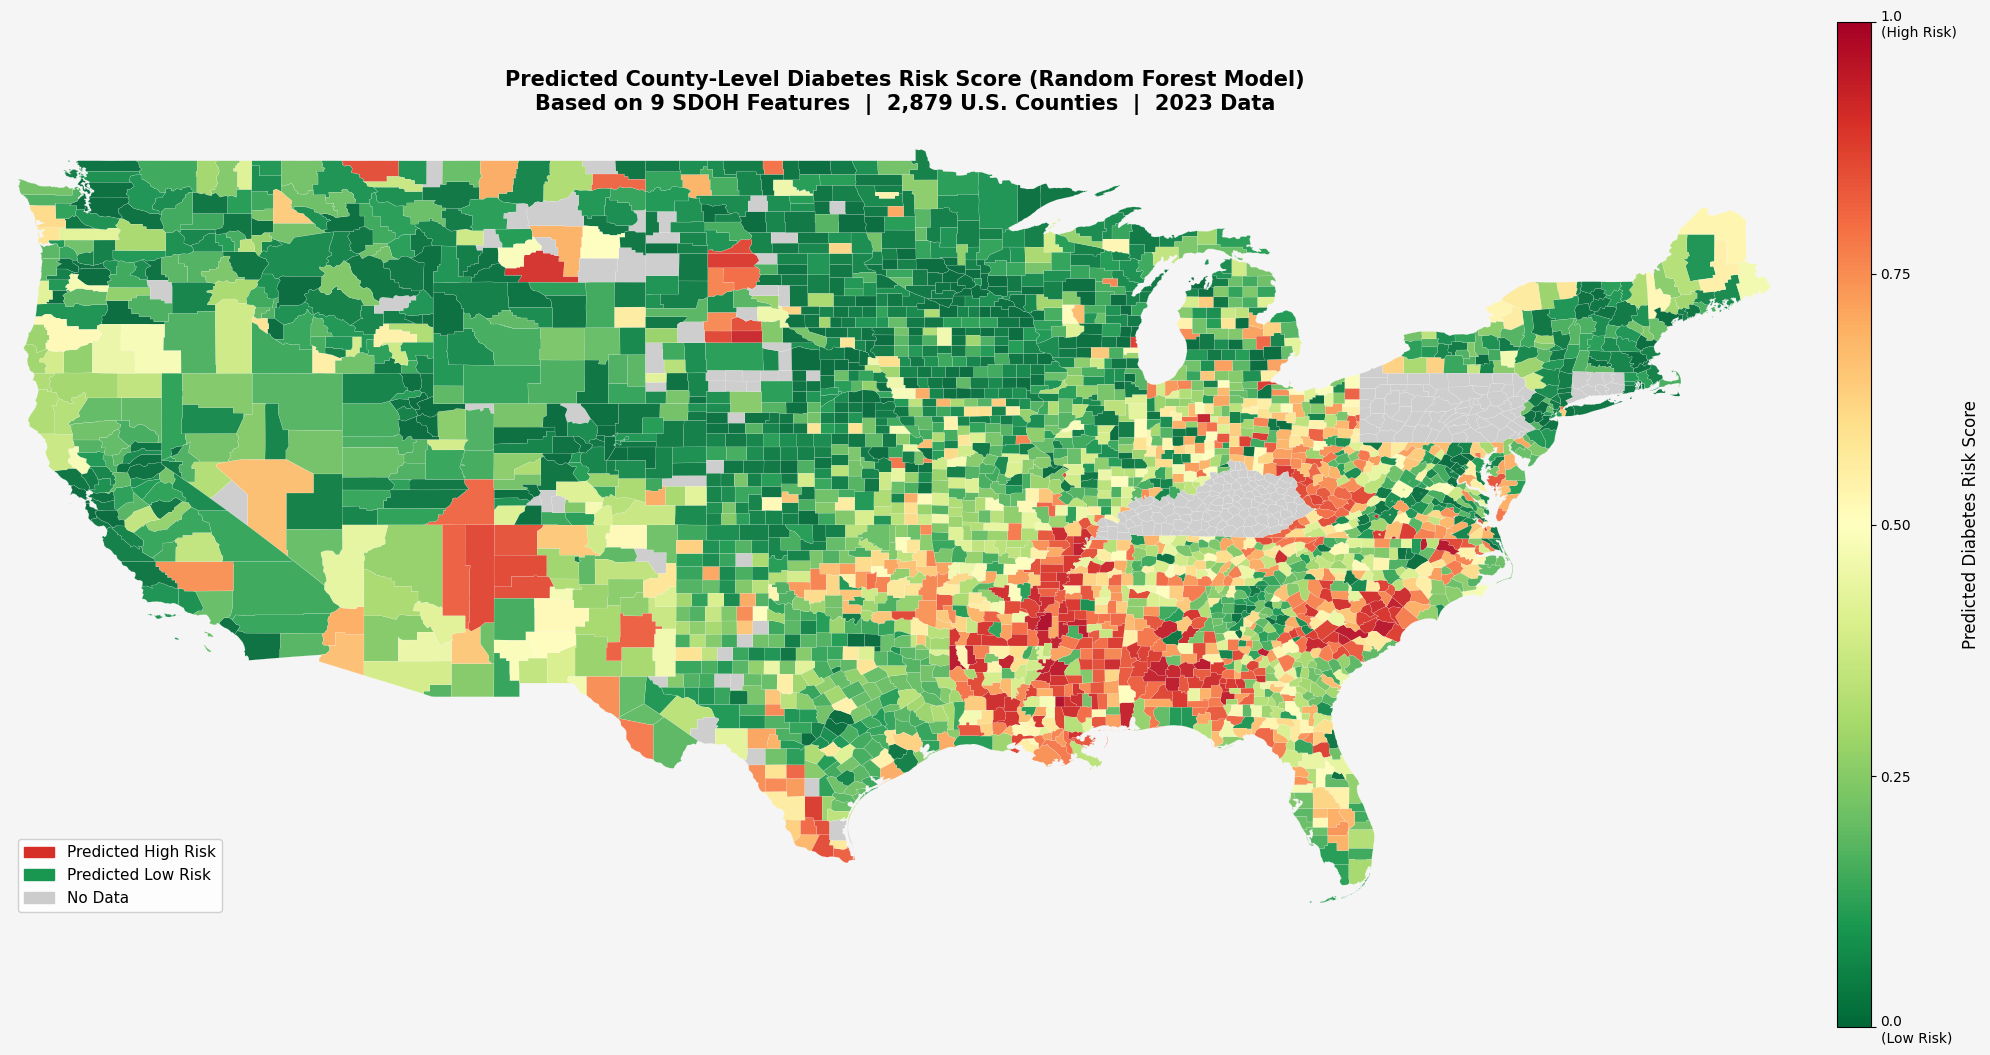

Static map saved — 3221 counties rendered.
Download: Colab Files panel (left sidebar → 📁 Files tab)


In [ ]:
# Static PNG version of the map, for written report

import json
import requests
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Download the county GeoJSON
print("Downloading county boundaries...")
geojson_url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
response = requests.get(geojson_url)
counties_geojson = response.json()
print(f"Loaded {len(counties_geojson['features'])} county boundaries")

# Build FIPS → risk score lookup
risk_lookup = dict(zip(
    final_df['fips_str'].astype(str).str.zfill(5),
    final_df['risk_score']
))
pred_lookup = dict(zip(
    final_df['fips_str'].astype(str).str.zfill(5),
    final_df['predicted_risk']
))

# Color mapping
cmap = plt.cm.get_cmap('RdYlGn_r')  # green=low risk, red=high risk
norm = Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(1, 1, figsize=(20, 12))
ax.set_facecolor('#e8f4f8')
fig.patch.set_facecolor('#f5f5f5')

print("Rendering counties (this may take ~30 seconds)...")
rendered = 0
for feature in counties_geojson['features']:
    fips = feature['properties']['STATE'] + feature['properties']['COUNTY']
    risk = risk_lookup.get(fips, None)

    if risk is None:
        color = '#cccccc'  # gray for missing data
    else:
        color = cmap(norm(risk))

    geom = feature['geometry']
    if geom['type'] == 'Polygon':
        polys = [geom['coordinates']]
    else:
        polys = geom['coordinates']

    for poly in polys:
        for ring in poly:
            coords = np.array(ring)
            if coords.ndim == 2 and coords.shape[1] >= 2:
                ax.fill(coords[:, 0], coords[:, 1],
                        color=color, linewidth=0.1,
                        edgecolor='white', alpha=0.95)
    rendered += 1

# Crop to continental US
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_aspect('equal')
ax.axis('off')

# Colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical',
                    fraction=0.018, pad=0.02, aspect=30)
cbar.set_label('Predicted Diabetes Risk Score', fontsize=12)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.0\n(Low Risk)', '0.25', '0.50', '0.75', '1.0\n(High Risk)'])

# Legend for predicted class
patch_high = mpatches.Patch(color=cmap(norm(0.9)), label='Predicted High Risk')
patch_low  = mpatches.Patch(color=cmap(norm(0.1)), label='Predicted Low Risk')
patch_na   = mpatches.Patch(color='#cccccc',        label='No Data')
ax.legend(handles=[patch_high, patch_low, patch_na],
          loc='lower left', fontsize=11, framealpha=0.9)

ax.set_title(
    'Predicted County-Level Diabetes Risk Score (Random Forest Model)\n'
    'Based on 9 SDOH Features  |  2,879 U.S. Counties  |  2023 Data',
    fontsize=15, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig("county_diabetes_risk_map.png", dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"Static map saved — {rendered} counties rendered.")
print("Download: Colab Files panel (left sidebar → 📁 Files tab)")

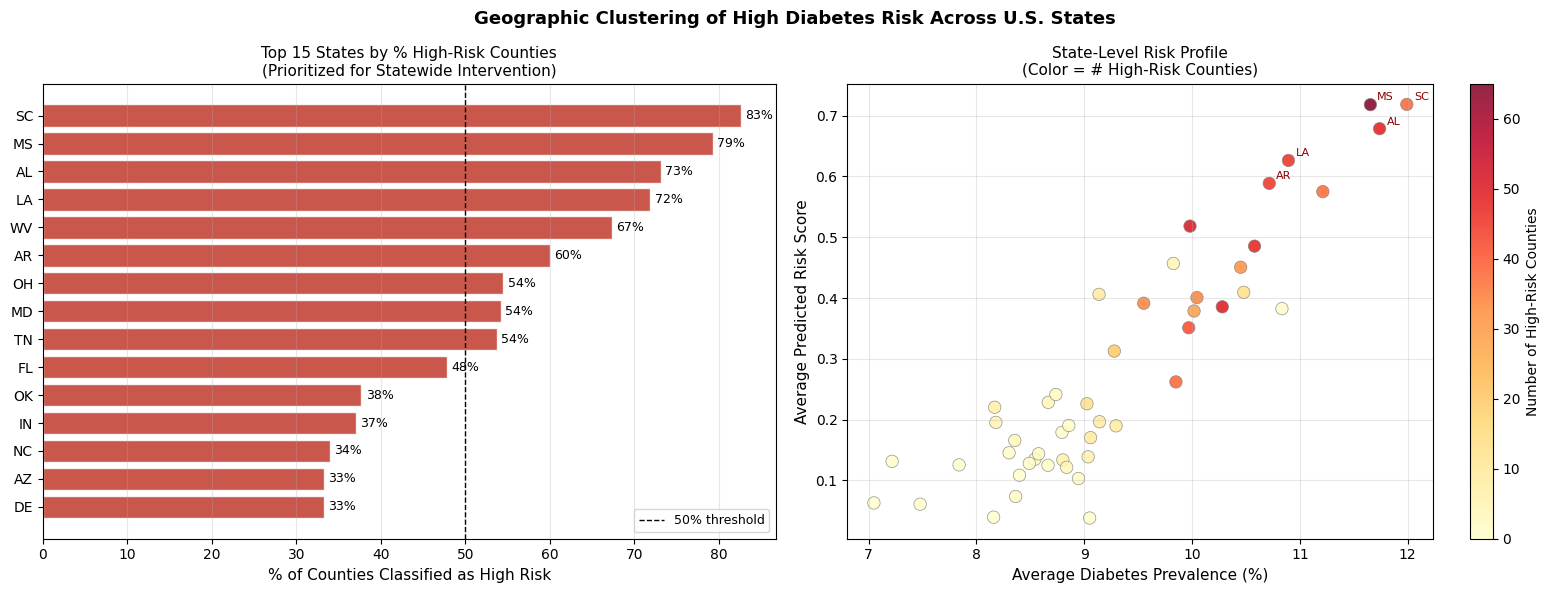

State-level cluster analysis complete.

Top 5 states by avg risk score:
State Abbreviation  avg_risk_score  avg_diabetes_pct  high_risk_counties
                SC           0.718            11.991                  38
                MS           0.718            11.654                  65
                AL           0.678            11.739                  49
                LA           0.626            10.894                  46
                AR           0.589            10.716                  45


In [ ]:
# State-Level Summary: Where are high-risk counties clustered?

# Merge state abbreviation back in from CHR data
if 'State Abbreviation' in chr_df.columns:
    state_map = chr_df[['5-digit FIPS Code', 'State Abbreviation']].drop_duplicates()
    final_df_state = final_df.merge(
        state_map, left_on='fips', right_on='5-digit FIPS Code', how='left'
    )
else:
    # Fallback: derive state from first 2 digits of FIPS
    fips_to_state = {
        '01':'AL','02':'AK','04':'AZ','05':'AR','06':'CA','08':'CO','09':'CT',
        '10':'DE','12':'FL','13':'GA','15':'HI','16':'ID','17':'IL','18':'IN',
        '19':'IA','20':'KS','21':'KY','22':'LA','23':'ME','24':'MD','25':'MA',
        '26':'MI','27':'MN','28':'MS','29':'MO','30':'MT','31':'NE','32':'NV',
        '33':'NH','34':'NJ','35':'NM','36':'NY','37':'NC','38':'ND','39':'OH',
        '40':'OK','41':'OR','42':'PA','44':'RI','45':'SC','46':'SD','47':'TN',
        '48':'TX','49':'UT','50':'VT','51':'VA','53':'WA','54':'WV','55':'WI',
        '56':'WY'
    }
    final_df_state = final_df.copy()
    final_df_state['State Abbreviation'] = \
        final_df_state['fips'].astype(str).str.zfill(5).str[:2].map(fips_to_state)

# Count high-risk counties per state
state_summary = (
    final_df_state.groupby('State Abbreviation')
    .agg(
        total_counties   = ('fips', 'count'),
        high_risk_counties = ('predicted_risk', 'sum'),
        avg_risk_score   = ('risk_score', 'mean'),
        avg_diabetes_pct = ('diabetes_prevalence', 'mean')
    )
    .reset_index()
)
state_summary['pct_high_risk'] = (
    state_summary['high_risk_counties'] / state_summary['total_counties'] * 100
).round(1)

# Top 15 states by % of counties that are high risk
top_states = state_summary.sort_values('pct_high_risk', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: % high-risk counties by state
bars = axes[0].barh(
    top_states['State Abbreviation'][::-1],
    top_states['pct_high_risk'][::-1],
    color='#C0392B', alpha=0.85, edgecolor='white'
)
axes[0].set_xlabel('% of Counties Classified as High Risk', fontsize=11)
axes[0].set_title('Top 15 States by % High-Risk Counties\n(Prioritized for Statewide Intervention)', fontsize=11)
axes[0].axvline(50, color='black', linestyle='--', linewidth=1, label='50% threshold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_states['pct_high_risk'][::-1]):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}%', va='center', fontsize=9)

# Scatter: avg diabetes % vs avg risk score colored by high-risk count
sc = axes[1].scatter(
    state_summary['avg_diabetes_pct'],
    state_summary['avg_risk_score'],
    c=state_summary['high_risk_counties'],
    cmap='YlOrRd', s=80, alpha=0.85, edgecolors='gray', linewidth=0.5
)
plt.colorbar(sc, ax=axes[1], label='Number of High-Risk Counties')
axes[1].set_xlabel('Average Diabetes Prevalence (%)', fontsize=11)
axes[1].set_ylabel('Average Predicted Risk Score', fontsize=11)
axes[1].set_title('State-Level Risk Profile\n(Color = # High-Risk Counties)', fontsize=11)

# Label the most concerning states
top5 = state_summary.sort_values('avg_risk_score', ascending=False).head(5)
for _, row in top5.iterrows():
    axes[1].annotate(
        row['State Abbreviation'],
        (row['avg_diabetes_pct'], row['avg_risk_score']),
        textcoords="offset points", xytext=(5, 3), fontsize=8, color='darkred'
    )
axes[1].grid(alpha=0.3)

plt.suptitle('Geographic Clustering of High Diabetes Risk Across U.S. States',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("state_risk_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("State-level cluster analysis complete.")
print(f"\nTop 5 states by avg risk score:")
print(top5[['State Abbreviation','avg_risk_score','avg_diabetes_pct',
            'high_risk_counties']].round(3).to_string(index=False))

## Data Engineering Pipeline: Supporting Ongoing Intervention

A one-time analysis is not sufficient for sustainable public health surveillance.
This section presents a **conceptual data pipeline design** that describes how
our county-level diabetes risk model can be refreshed **annually** using
publicly available federal datasets — enabling ongoing monitoring and
intervention targeting without manual re-analysis.

**Pipeline Goals:**
- 🔄 Automate annual data ingestion from CDC and ACS sources
- 🔗 Maintain FIPS-based county linkage across all datasets
- 📊 Re-score all counties each year using the trained Random Forest model
- 🚨 Flag counties whose risk tier has changed (low → high) for priority outreach
- 📡 Feed updated scores into the public-facing dashboard for policymakers

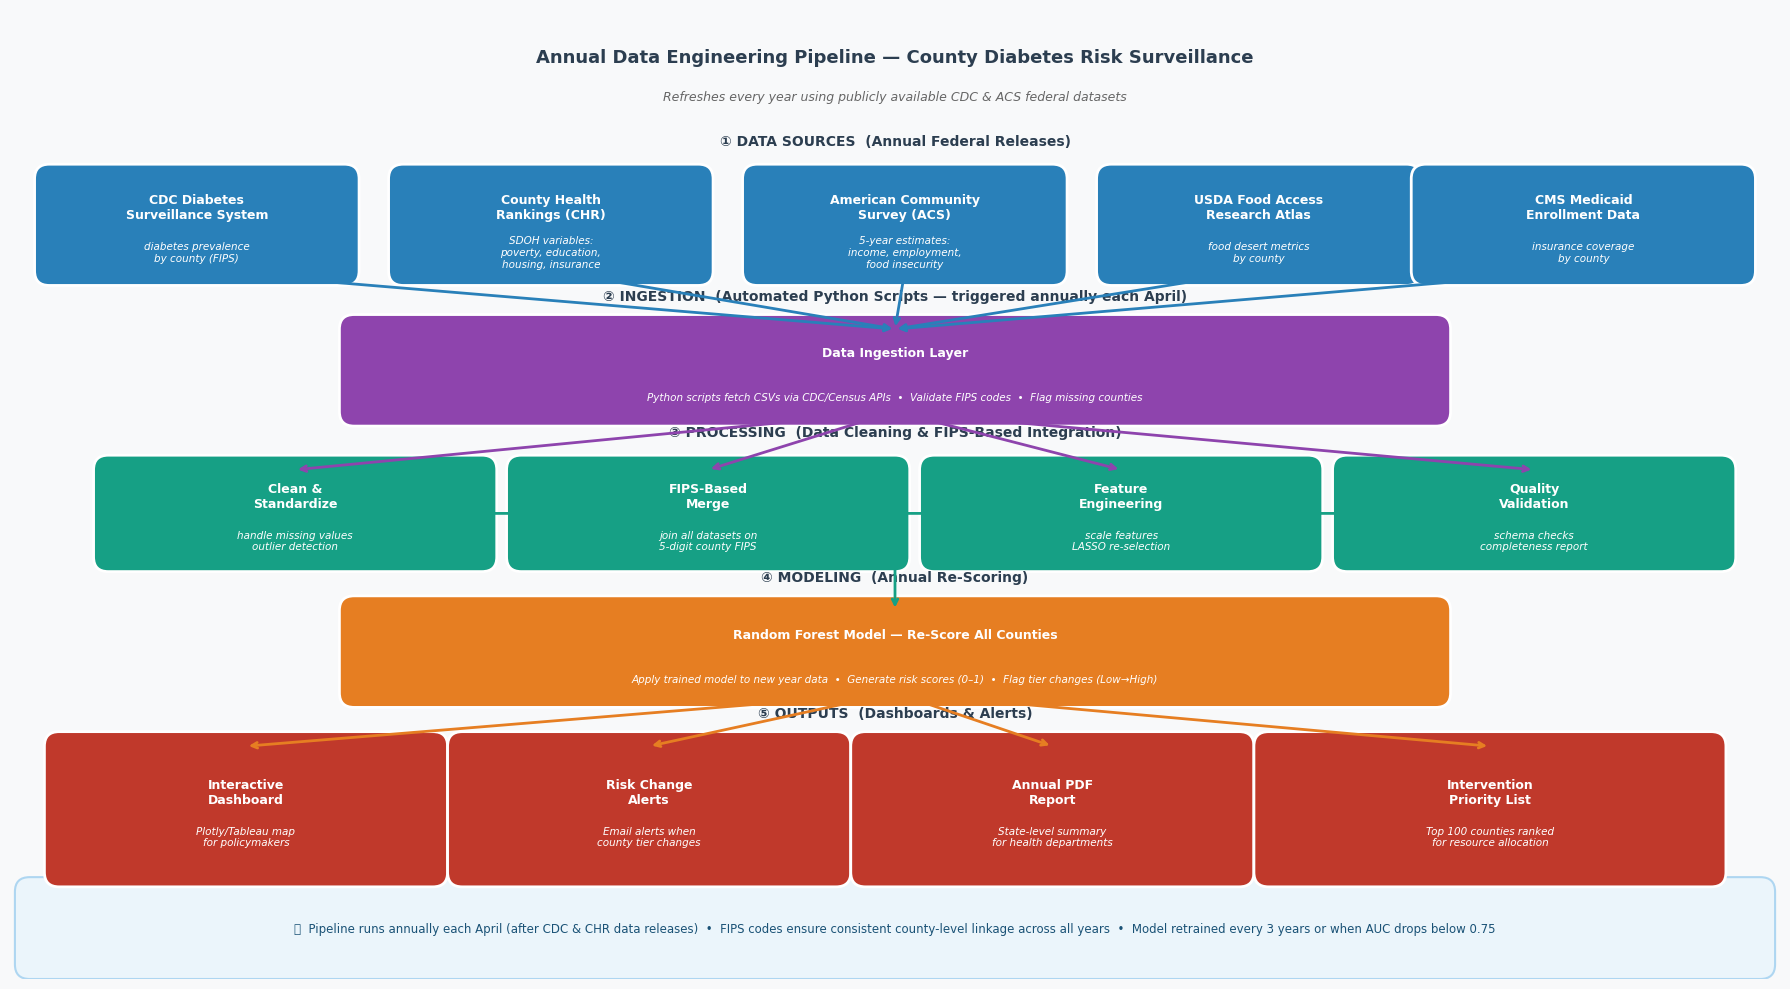

Data Engineering Pipeline diagram saved as 'data_pipeline.png'


In [ ]:
# Data Engineering Pipeline: Architecture Diagram
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 18)
ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

# Helper functions
def draw_box(ax, x, y, w, h, label, sublabel='', color='#4C9BE8',
             fontsize=9, text_color='white'):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.15",
        facecolor=color, edgecolor='white', linewidth=2, zorder=3
    ))
    ax.text(x + w/2, y + h/2 + (0.18 if sublabel else 0),
            label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold',
            color=text_color, zorder=4)
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.28, sublabel,
                ha='center', va='center',
                fontsize=7.5, color=text_color,
                style='italic', zorder=4)

def draw_arrow(ax, x1, y1, x2, y2, color='#555555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle='->', color=color,
                    lw=2.0, connectionstyle='arc3,rad=0.0'
                ), zorder=5)

def draw_label(ax, x, y, text, fontsize=8, color='#444444'):
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color=color,
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor='white', edgecolor='#cccccc',
                      linewidth=1), zorder=6)

# LAYER 0: Title
ax.text(9, 9.5, 'Annual Data Engineering Pipeline — County Diabetes Risk Surveillance',
        ha='center', va='center', fontsize=13,
        fontweight='bold', color='#2C3E50')
ax.text(9, 9.1, 'Refreshes every year using publicly available CDC & ACS federal datasets',
        ha='center', va='center', fontsize=9, color='#666666', style='italic')

# LAYER 1: Data Sources
ax.text(9, 8.6, '① DATA SOURCES  (Annual Federal Releases)',
        ha='center', fontsize=10, fontweight='bold', color='#2C3E50')

sources = [
    (0.4,  7.3, 3.0, 0.95, 'CDC Diabetes\nSurveillance System',
     'diabetes prevalence\nby county (FIPS)', '#2980B9'),
    (4.0,  7.3, 3.0, 0.95, 'County Health\nRankings (CHR)',
     'SDOH variables:\npoverty, education,\nhousing, insurance', '#2980B9'),
    (7.6,  7.3, 3.0, 0.95, 'American Community\nSurvey (ACS)',
     '5-year estimates:\nincome, employment,\nfood insecurity', '#2980B9'),
    (11.2, 7.3, 3.0, 0.95, 'USDA Food Access\nResearch Atlas',
     'food desert metrics\nby county', '#2980B9'),
    (14.4, 7.3, 3.2, 0.95, 'CMS Medicaid\nEnrollment Data',
     'insurance coverage\nby county', '#2980B9'),
]
for args in sources:
    draw_box(ax, *args)

# LAYER 2: Ingestion
ax.text(9, 7.0, '② INGESTION  (Automated Python Scripts — triggered annually each April)',
        ha='center', fontsize=10, fontweight='bold', color='#2C3E50')

draw_box(ax, 3.5, 5.85, 11.0, 0.85,
         'Data Ingestion Layer',
         'Python scripts fetch CSVs via CDC/Census APIs  •  '
         'Validate FIPS codes  •  Flag missing counties',
         '#8E44AD', fontsize=9)

# Arrows: sources → ingestion
for sx in [1.9, 5.5, 9.1, 12.7, 16.0]:
    draw_arrow(ax, sx, 7.3, 9.0, 6.7, '#2980B9')

# LAYER 3: Processing
ax.text(9, 5.6, '③ PROCESSING  (Data Cleaning & FIPS-Based Integration)',
        ha='center', fontsize=10, fontweight='bold', color='#2C3E50')

proc_boxes = [
    (1.0,  4.35, 3.8, 0.9, 'Clean &\nStandardize',
     'handle missing values\noutlier detection', '#16A085'),
    (5.2,  4.35, 3.8, 0.9, 'FIPS-Based\nMerge',
     'join all datasets on\n5-digit county FIPS', '#16A085'),
    (9.4,  4.35, 3.8, 0.9, 'Feature\nEngineering',
     'scale features\nLASSO re-selection', '#16A085'),
    (13.6, 4.35, 3.8, 0.9, 'Quality\nValidation',
     'schema checks\ncompleteness report', '#16A085'),
]
for args in proc_boxes:
    draw_box(ax, *args)

# Arrows: ingestion → processing boxes
for tx in [2.9, 7.1, 11.3, 15.5]:
    draw_arrow(ax, 9.0, 5.85, tx, 5.25, '#8E44AD')

# Arrows between processing boxes
for x1, x2 in [(4.8, 5.2), (9.0, 9.4), (13.2, 13.6)]:
    draw_arrow(ax, x1, 4.8, x2, 4.8, '#16A085')

# Layer 4: Modeling
ax.text(9, 4.1, '④ MODELING  (Annual Re-Scoring)',
        ha='center', fontsize=10, fontweight='bold', color='#2C3E50')

draw_box(ax, 3.5, 2.95, 11.0, 0.85,
         'Random Forest Model — Re-Score All Counties',
         'Apply trained model to new year data  •  '
         'Generate risk scores (0–1)  •  Flag tier changes (Low→High)',
         '#E67E22', fontsize=9)

# Arrow: processing → modeling
draw_arrow(ax, 9.0, 4.35, 9.0, 3.8, '#16A085')

# LAYER 5: Outputs
ax.text(9, 2.7, '⑤ OUTPUTS  (Dashboards & Alerts)',
        ha='center', fontsize=10, fontweight='bold', color='#2C3E50')

output_boxes = [
    (0.5,  1.1, 3.8, 1.3,
     'Interactive\nDashboard',
     'Plotly/Tableau map\nfor policymakers', '#C0392B'),
    (4.6,  1.1, 3.8, 1.3,
     'Risk Change\nAlerts',
     'Email alerts when\ncounty tier changes', '#C0392B'),
    (8.7,  1.1, 3.8, 1.3,
     'Annual PDF\nReport',
     'State-level summary\nfor health departments', '#C0392B'),
    (12.8, 1.1, 4.5, 1.3,
     'Intervention\nPriority List',
     'Top 100 counties ranked\nfor resource allocation', '#C0392B'),
]
for args in output_boxes:
    draw_box(ax, *args)

# Arrows: modeling → outputs
for ox in [2.4, 6.5, 10.6, 15.05]:
    draw_arrow(ax, 9.0, 2.95, ox, 2.4, '#E67E22')

# Annotation: refresh cadence
ax.add_patch(mpatches.FancyBboxPatch(
    (0.2, 0.15), 17.6, 0.75,
    boxstyle="round,pad=0.15",
    facecolor='#EBF5FB', edgecolor='#AED6F1', linewidth=1.5, zorder=2
))
ax.text(9, 0.52,
        '🔄  Pipeline runs annually each April (after CDC & CHR data releases)  •  '
        'FIPS codes ensure consistent county-level linkage across all years  •  '
        'Model retrained every 3 years or when AUC drops below 0.75',
        ha='center', va='center', fontsize=8.5, color='#1A5276', zorder=3)

plt.tight_layout()
plt.savefig("data_pipeline.png", dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Data Engineering Pipeline diagram saved as 'data_pipeline.png'")

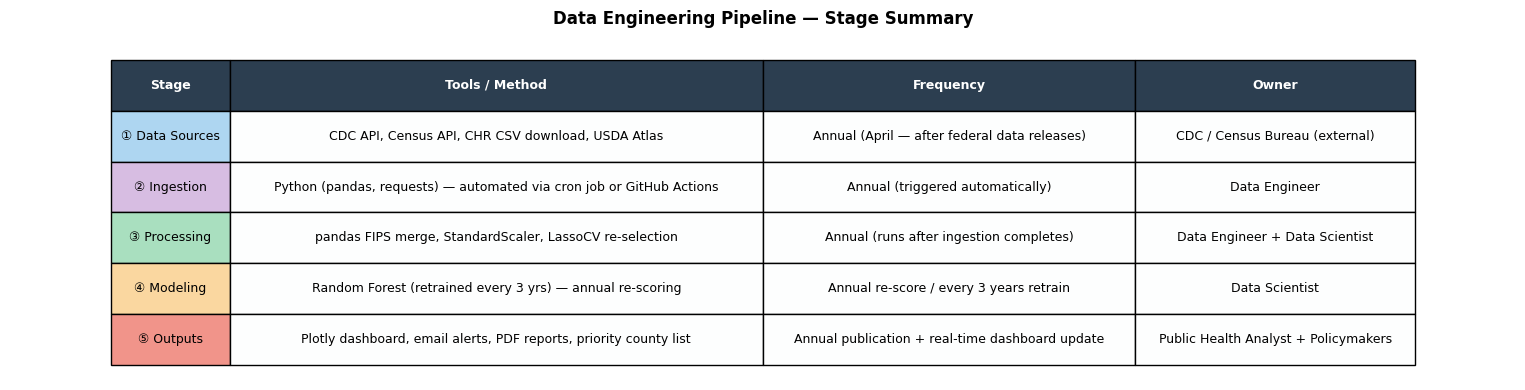

Pipeline summary table saved as 'pipeline_summary_table.png'


In [ ]:
# Pipeline Summary Table

pipeline_summary = {
    'Stage': [
        '① Data Sources',
        '② Ingestion',
        '③ Processing',
        '④ Modeling',
        '⑤ Outputs'
    ],
    'Tools / Method': [
        'CDC API, Census API, CHR CSV download, USDA Atlas',
        'Python (pandas, requests) — automated via cron job or GitHub Actions',
        'pandas FIPS merge, StandardScaler, LassoCV re-selection',
        'Random Forest (retrained every 3 yrs) — annual re-scoring',
        'Plotly dashboard, email alerts, PDF reports, priority county list'
    ],
    'Frequency': [
        'Annual (April — after federal data releases)',
        'Annual (triggered automatically)',
        'Annual (runs after ingestion completes)',
        'Annual re-score / every 3 years retrain',
        'Annual publication + real-time dashboard update'
    ],
    'Owner': [
        'CDC / Census Bureau (external)',
        'Data Engineer',
        'Data Engineer + Data Scientist',
        'Data Scientist',
        'Public Health Analyst + Policymakers'
    ]
}

pipeline_df = pd.DataFrame(pipeline_summary)

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

stage_colors = {
    '① Data Sources': '#AED6F1',
    '② Ingestion':    '#D7BDE2',
    '③ Processing':   '#A9DFBF',
    '④ Modeling':     '#FAD7A0',
    '⑤ Outputs':      '#F1948A'
}

cell_colors = []
for _, row in pipeline_df.iterrows():
    row_color = stage_colors.get(row['Stage'], '#FFFFFF')
    cell_colors.append([row_color, '#FDFEFE', '#FDFEFE', '#FDFEFE'])

table = ax.table(
    cellText=pipeline_df.values,
    colLabels=pipeline_df.columns,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.8)

for j in range(len(pipeline_df.columns)):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Wider columns for text-heavy cells
table.auto_set_column_width([0, 1, 2, 3])

plt.title('Data Engineering Pipeline — Stage Summary',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("pipeline_summary_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("Pipeline summary table saved as 'pipeline_summary_table.png'")

### Pipeline Design Rationale

**Why FIPS codes as the linking key?**
Every dataset used in this project — CDC Diabetes Surveillance, County Health
Rankings, ACS, USDA Food Atlas, and CMS Medicaid data — publishes county-level
data with a standardized 5-digit Federal Information Processing Standards (FIPS)
code. This makes FIPS the natural, stable primary key for annual joins across
all data sources, ensuring consistent county-level linkage even when county
names change or are formatted differently across datasets.

**Why annual refresh instead of real-time?**
CDC Diabetes Surveillance and County Health Rankings data are released annually
(typically each April), so real-time ingestion is not possible or meaningful.
An annual pipeline triggered each April ensures the model always uses the most
current available data.

**Why retrain the model every 3 years?**
SDOH patterns shift gradually over time — major policy changes (e.g., Medicaid
expansion, SNAP reforms) can alter the relationship between predictors and
diabetes risk. We recommend monitoring AUC on the held-out test set each year,
and triggering a full model retrain if AUC drops below 0.75 or every 3 years,
whichever comes first.

**Why GitHub Actions / cron for automation?**
Both tools are free, version-controlled, and auditable — important for public
health infrastructure where reproducibility and transparency are critical.
Every pipeline run produces a log file documenting data shapes, missing county
counts, and model performance metrics for that year.

## CDC Population Health Competencies: How This Project Addresses #1–7

The professor requires incorporating as many of the CDC Population Health
Competencies as possible. Here is how this project explicitly addresses each:

| # | Competency | How Our Project Addresses It |
|---|---|---|
| 1 | Assess health status using surveillance data | Used CDC Diabetes Surveillance System (2023) and County Health Rankings — both federal public health surveillance datasets — to assess diabetes burden across 2,879 counties |
| 2 | Discuss SDOH and environmental determinants | Core of our analysis: poverty, education, housing, income, and rurality are all SDOH variables modeled as predictors of diabetes risk |
| 3 | Integrate biologic/genetic risk with population-level factors | Premature death rate (a proxy for chronic disease burden including genetic predisposition) was the strongest predictor in both models, integrated with SDOH factors |
| 4 | Appraise quality of peer-reviewed evidence | Project proposal cites peer-reviewed literature (Berkowitz et al. 2018; Hill et al. 2013; Kolak et al. 2020) to justify SDOH variable selection and intervention choices |
| 5 | Apply prevention strategies for individuals and populations | All proposed interventions (CDC National DPP, SNAP outreach, mobile clinics, Medicaid expansion) are evidence-based primary and secondary prevention strategies |
| 6 | Identify community assets and resources | Intervention matrix identifies specific agencies and programs (FQHCs, SNAP, ACA marketplace, housing authorities) as community resources for high-risk counties |
| 7 | Explain community-engagement strategies to reduce health disparities | Interventions explicitly target underserved populations (uninsured, rural, low-income, high child-poverty counties) to reduce diabetes-related health disparities |

## Conclusion

This project demonstrated that **Social Determinants of Health alone can
meaningfully predict county-level diabetes risk**, with our Random Forest model
achieving an AUC of 0.829 and our Logistic Regression achieving 0.791 across
2,879 U.S. counties.

**Key findings:**
- **Premature Death Rate** and **Children in Poverty** were the two strongest
  predictors of high diabetes risk in both models — indicating that mortality
  burden and economic deprivation are the most actionable targets for intervention.
- **% Rural** had a strong negative effect (lower rurality = lower risk in some
  contexts), but rural counties were disproportionately represented among the
  highest-risk tier, highlighting geographic health equity concerns.
- **Median Household Income** and **Some College** (education) were negatively
  correlated with diabetes risk — confirming that economic and educational
  investment in communities is a form of diabetes prevention.

**Limitations:**
- County-level analysis cannot identify individual risk — results should be used
  for population-level resource allocation, not individual diagnosis.
- 2023 data only — a longitudinal pipeline (see Data Engineering section) is
  needed for ongoing surveillance.
- The ACS dataset was not incorporated in the final model due to overlap with
  County Health Rankings variables; future work should explore ACS-specific
  features such as food insecurity and housing tenure.

**Impact:** By identifying high-risk counties using publicly available SDOH data,
this framework gives county health officials and policymakers a **reproducible,
annually updatable screening tool** to prioritize diabetes prevention resources
where they are needed most — directly aligned with the CDC HI-5 goal of achieving
measurable population health impact within 5 years.